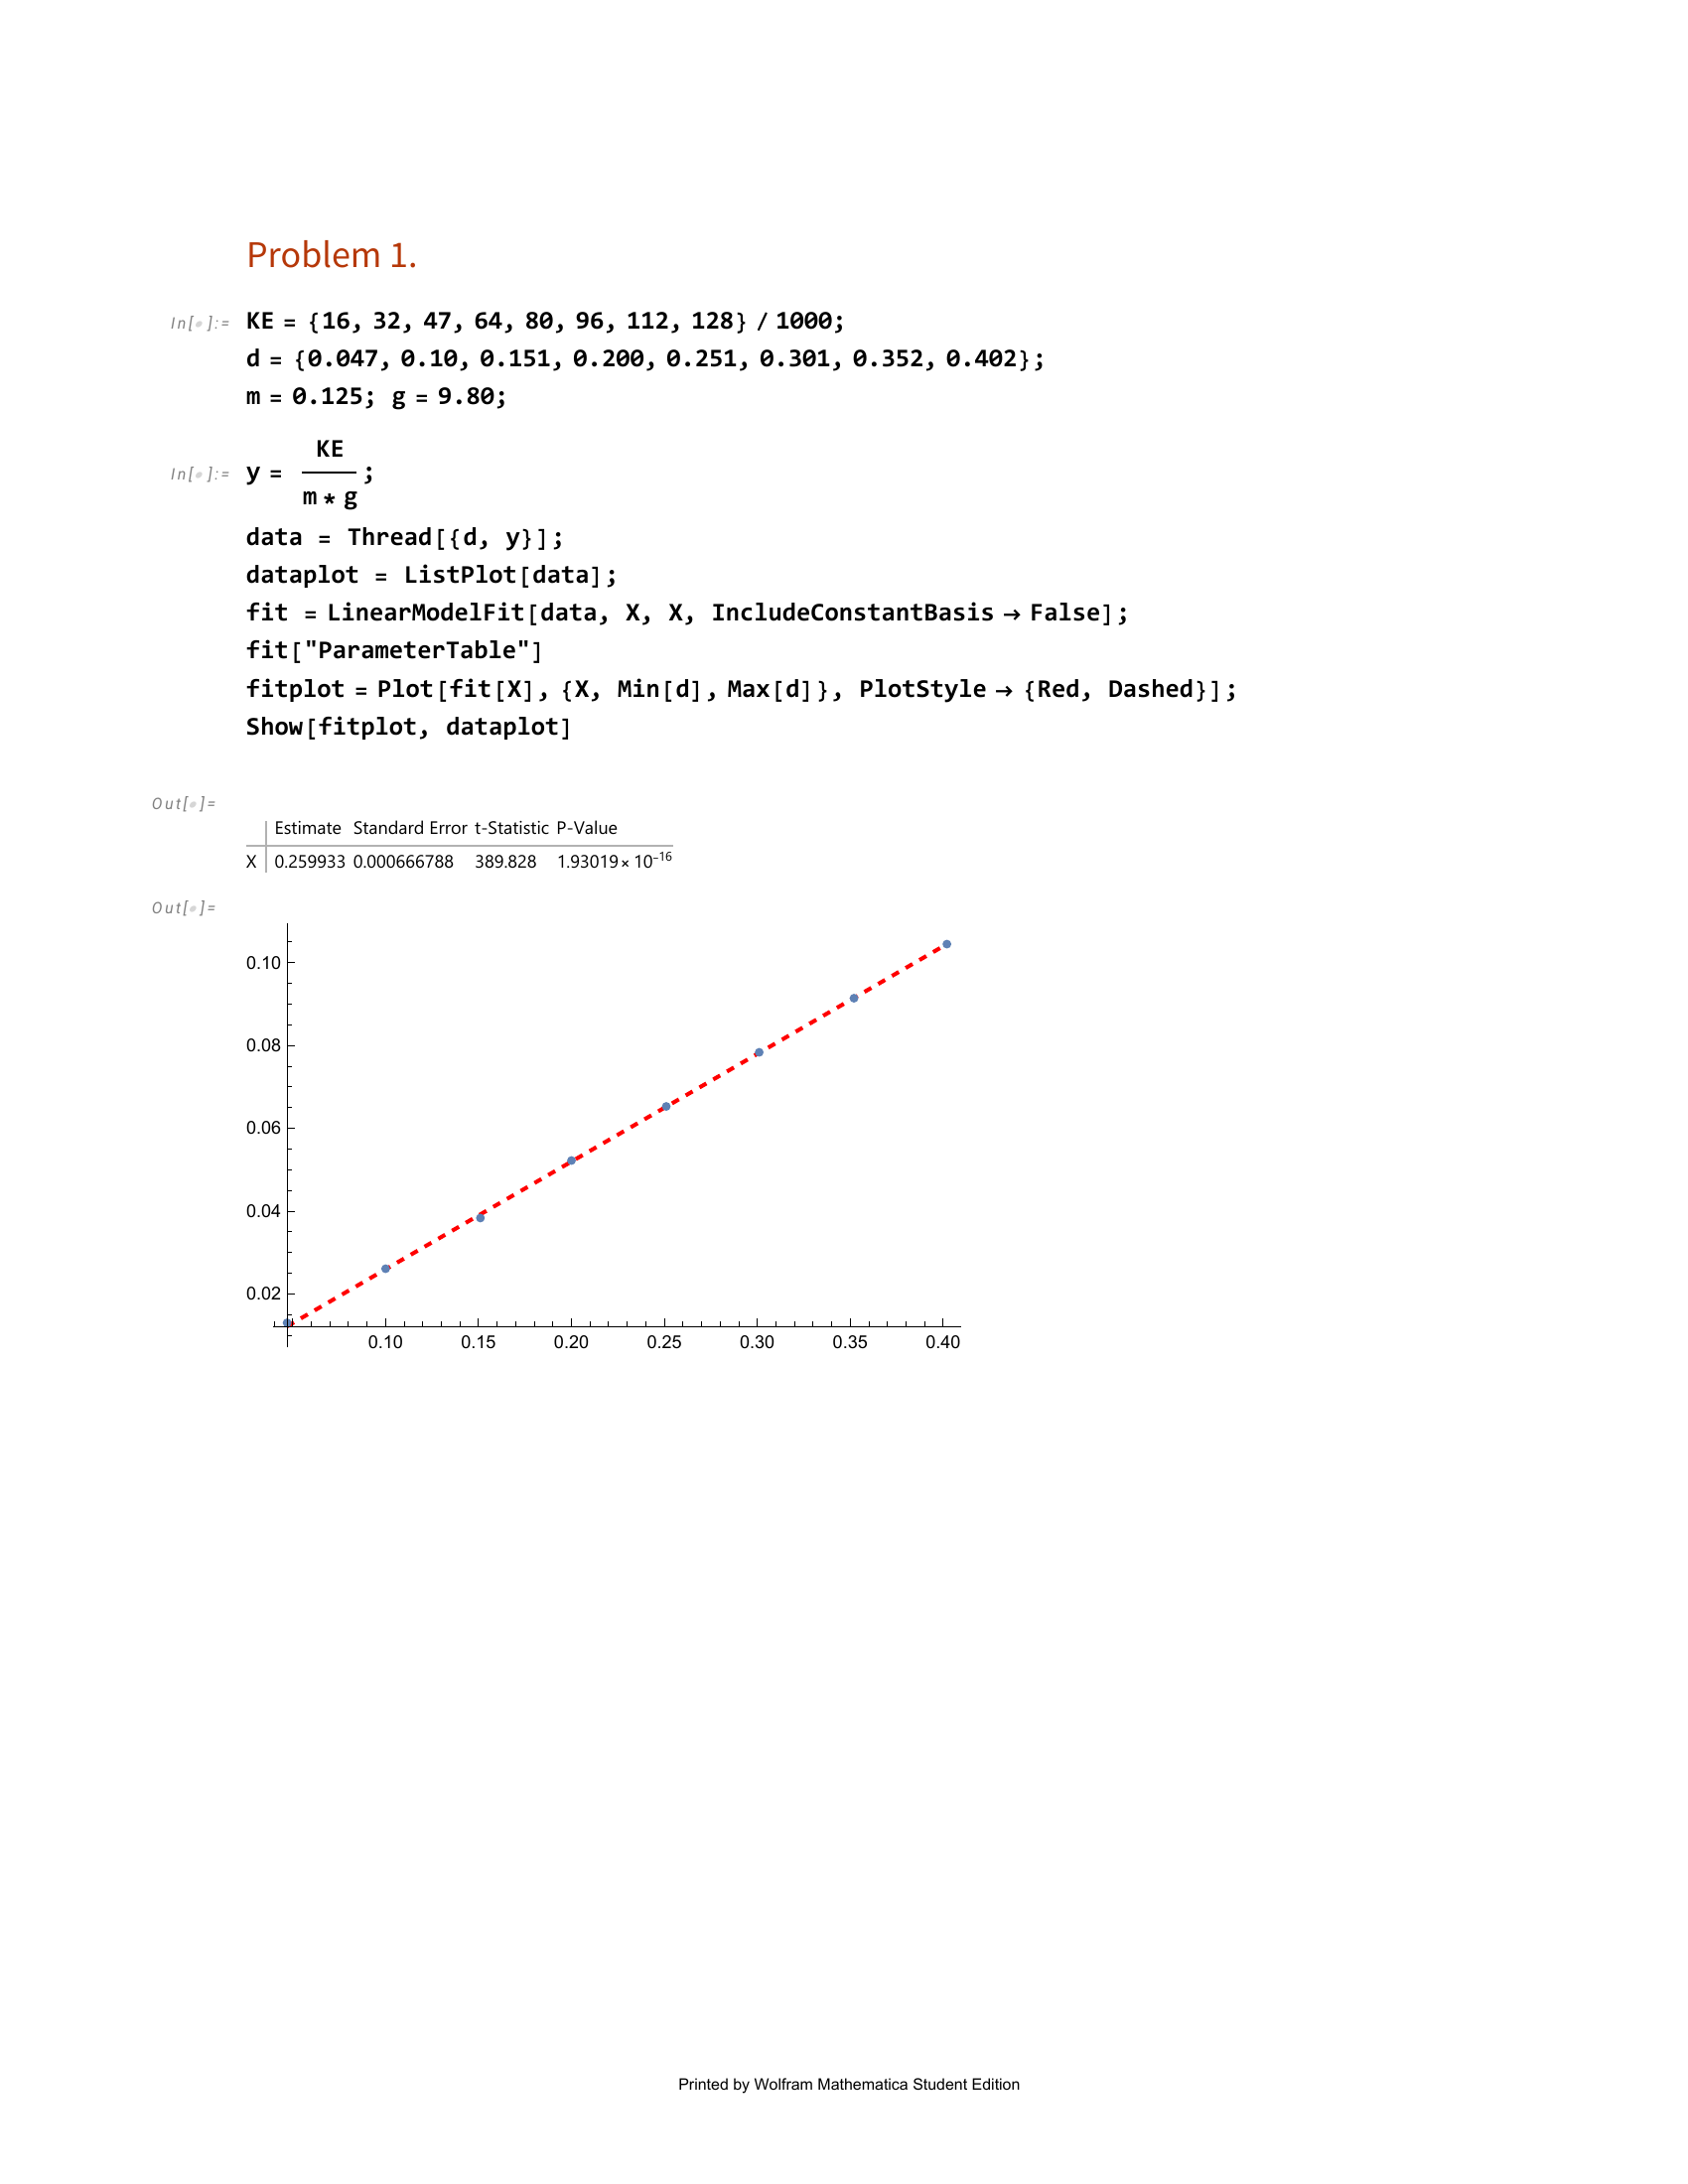

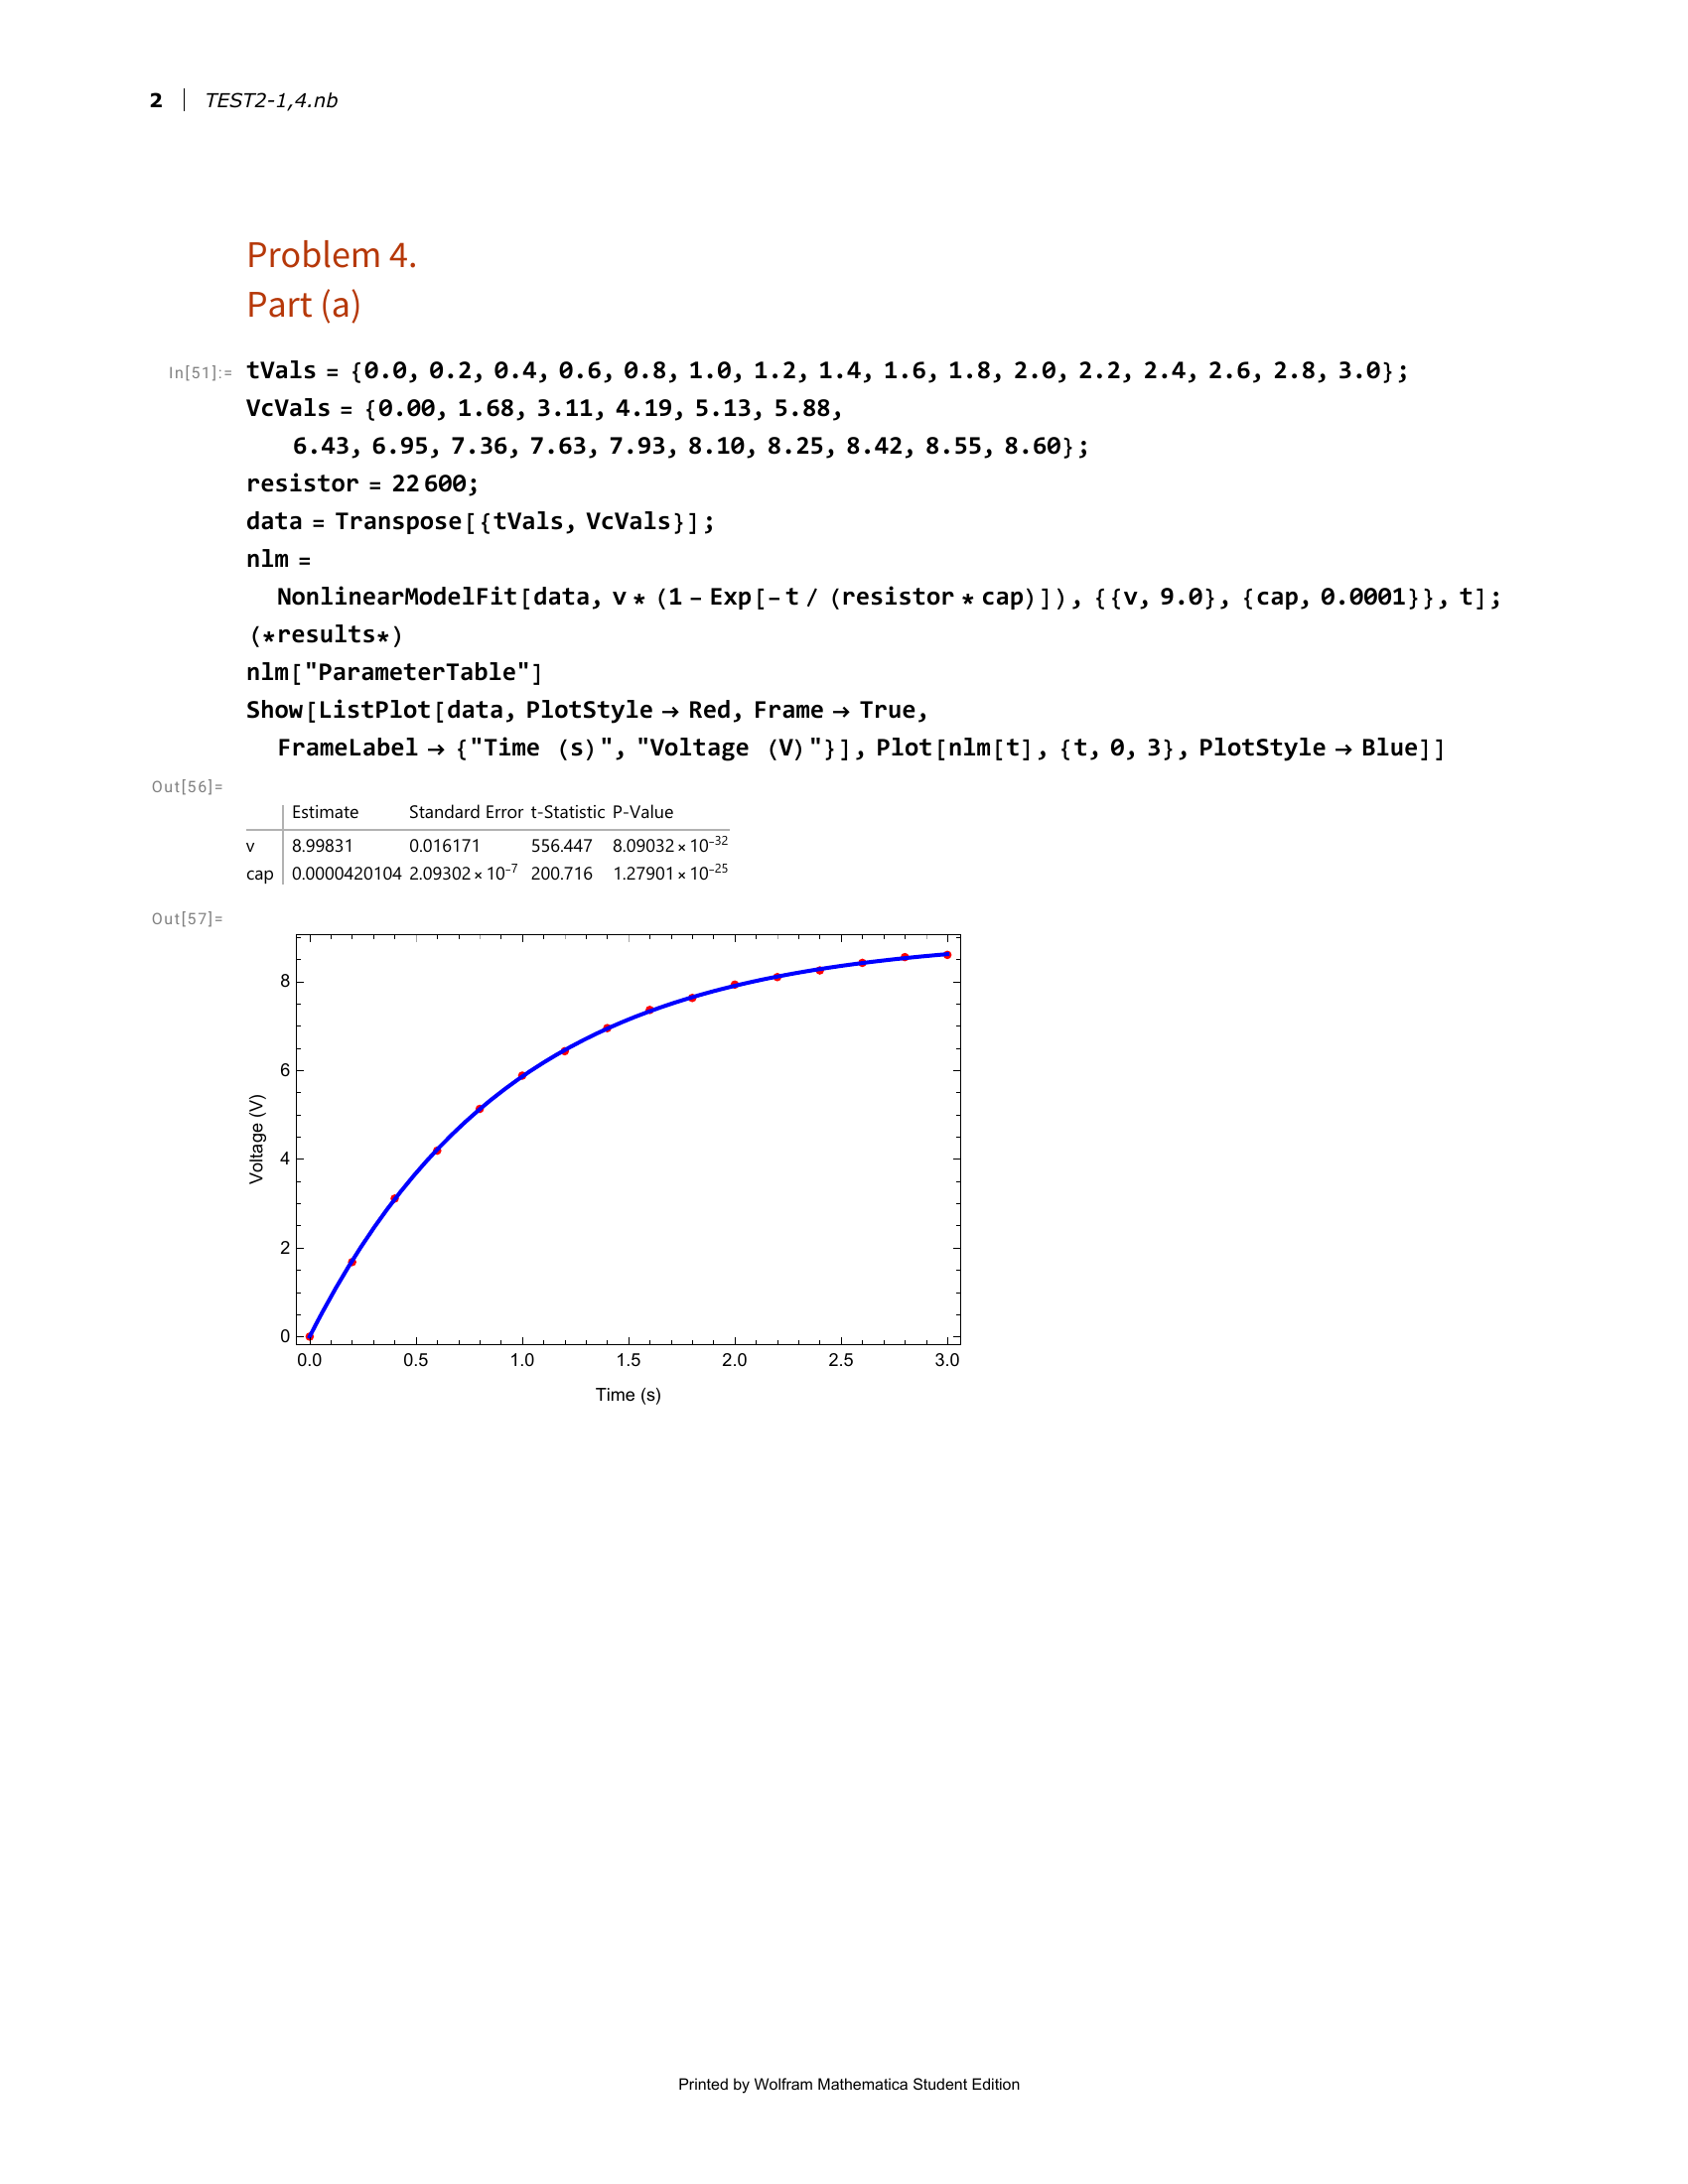

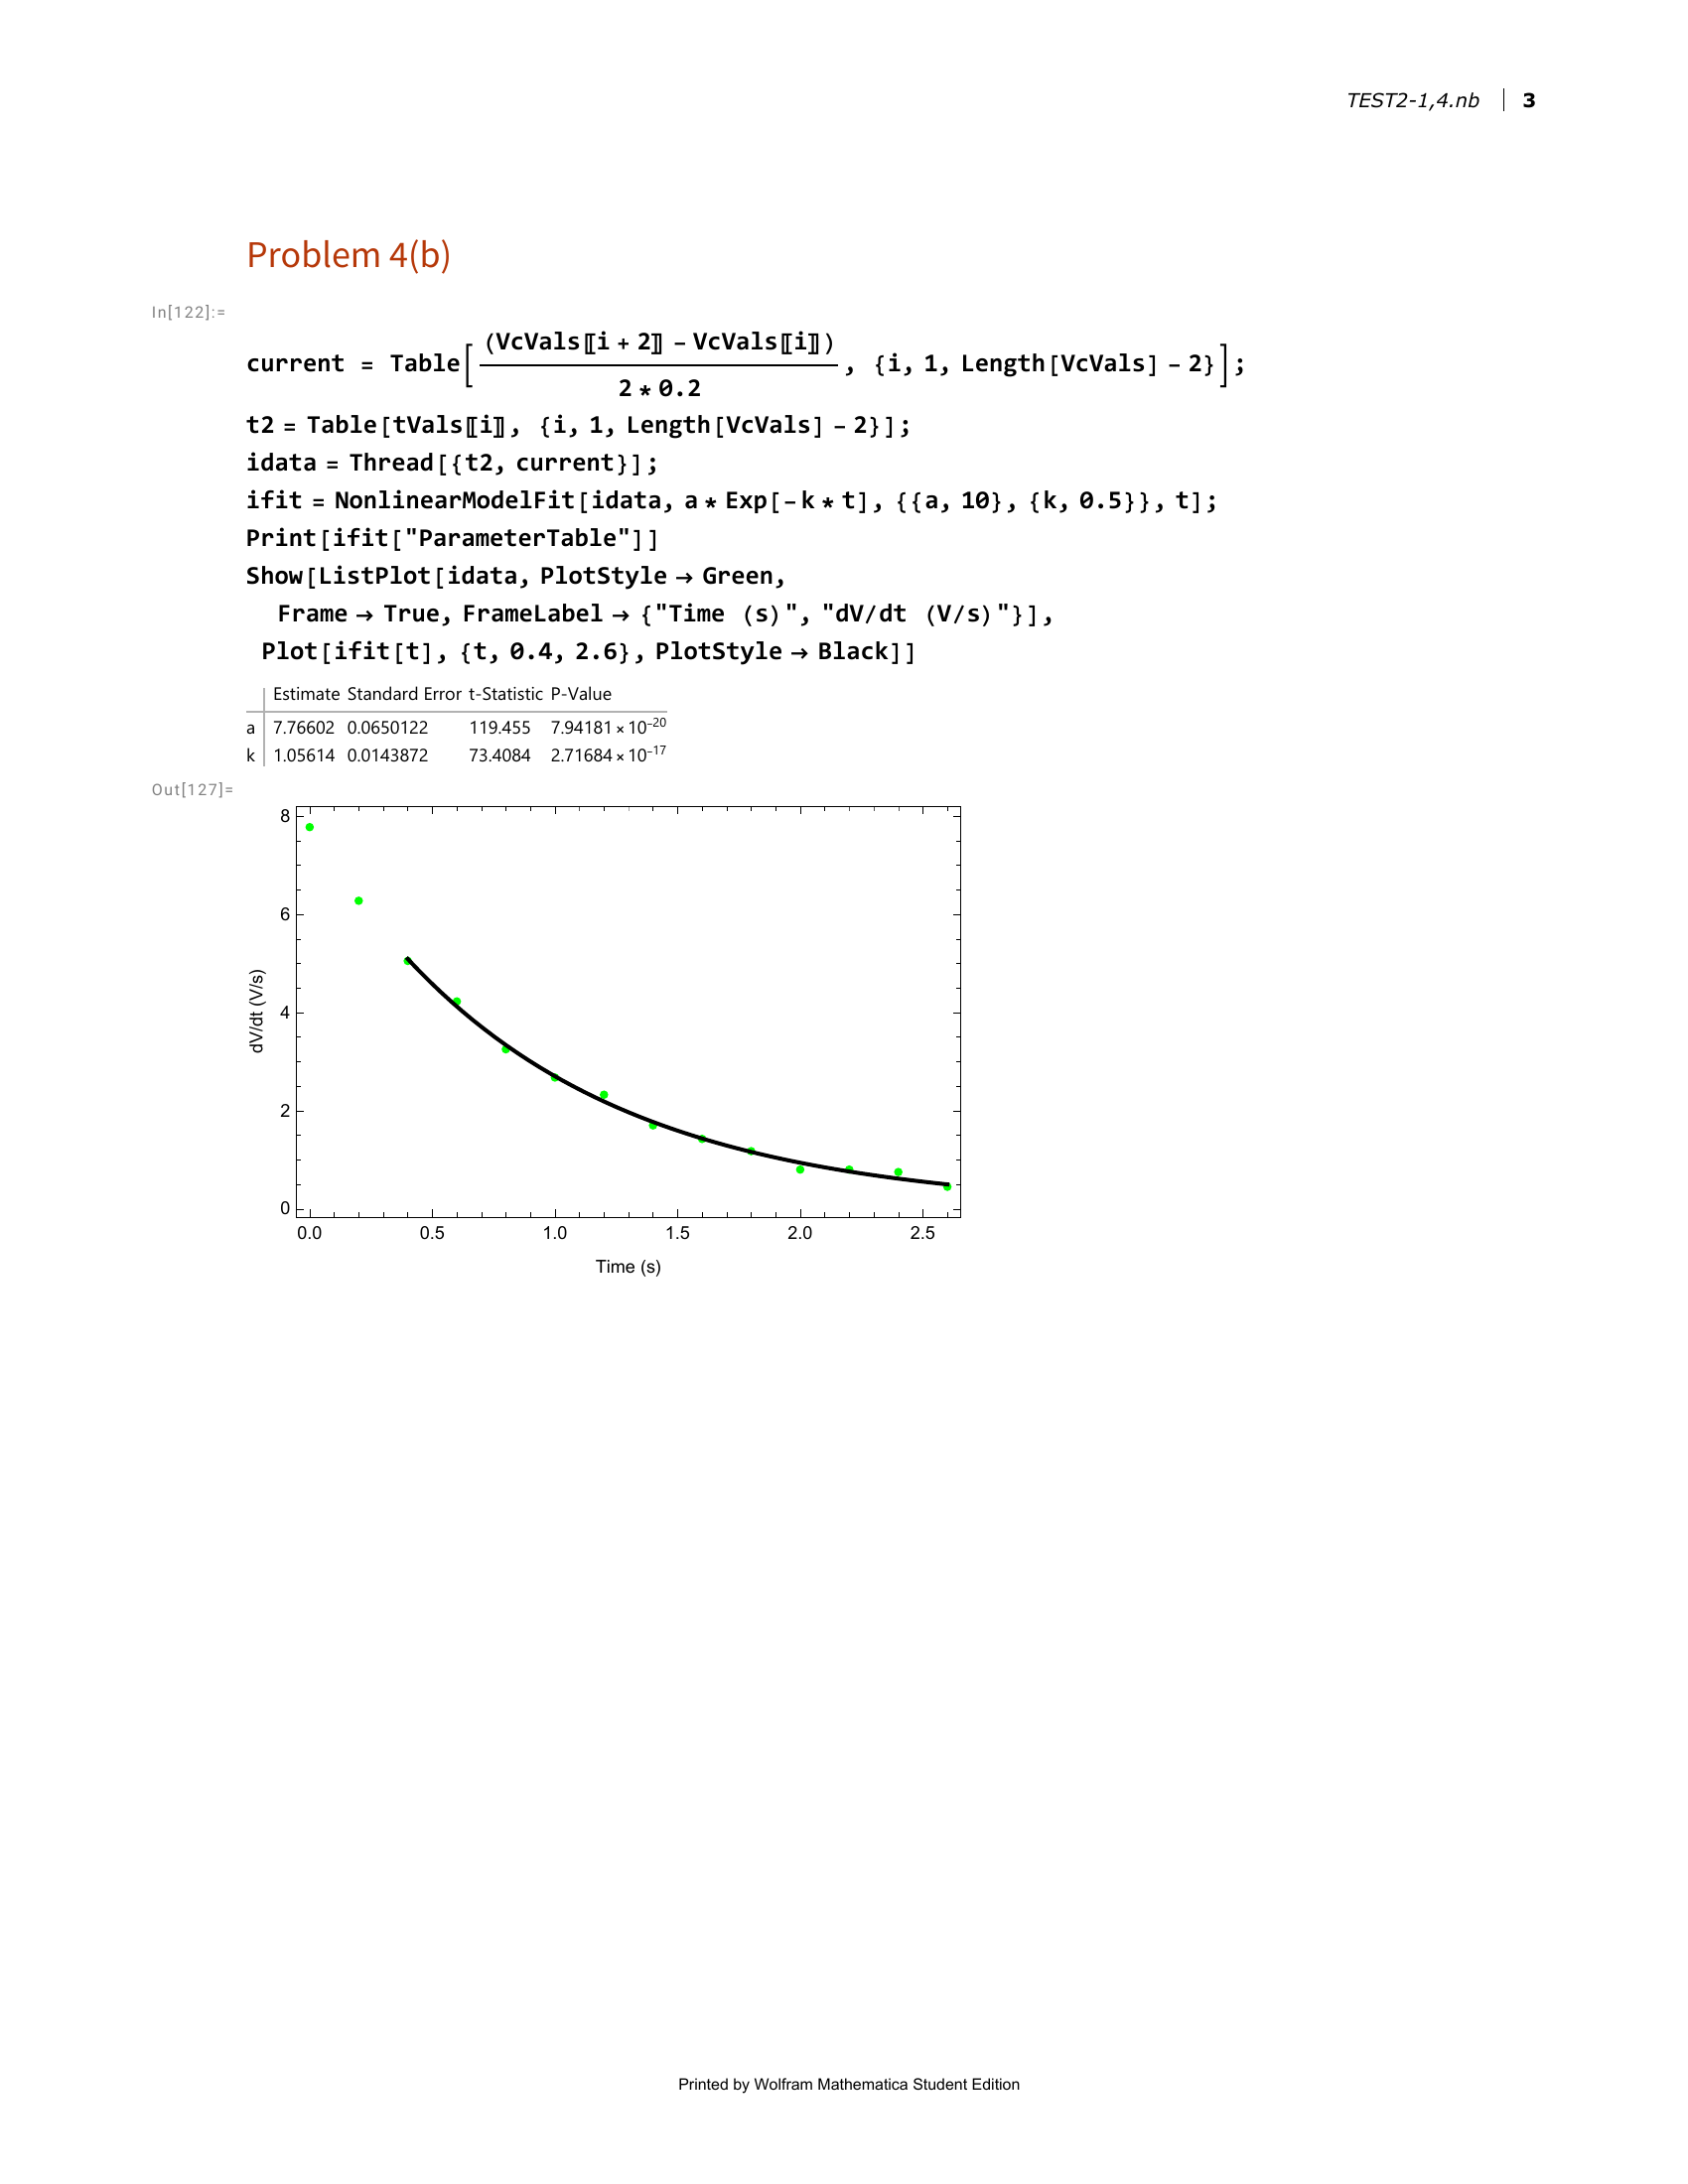

In [73]:
from pdf2image import convert_from_path
from IPython.display import display
images = convert_from_path(r"C:\Users\miles\BYU-Idaho\11th Semester\336 Advanced Lab\TESTS\TEST2\TEST2-1,4.pdf")
for img in images:
    display(img)

### Problem 2.

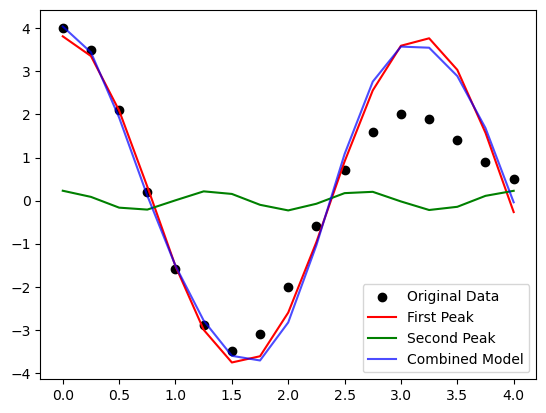

Force 1: A1=3.82, omega1=1.98
Force 2: A2=0.23, omega2=4.74


In [42]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

t=np.arange(0.00, 4.25, 0.25)
x=np.array([4.0, 3.5, 2.1, 0.2, -1.6, -2.9, -3.5, -3.1, -2.0, 
            -0.6, 0.7, 1.6, 2.0, 1.9, 1.4, 0.9, 0.5])

def f(t, A, omega):
    return A*np.cos(omega*t)

min_index=np.argmin(x)
min_x=min(x)
valley=t[min_index]
tA1=t[:min_index+1]
xA1=x[:min_index+1]

initial_guess=[np.argmax(x), 2]
popt, pcov = curve_fit(f, tA1, xA1, p0 = initial_guess)

xA2= x-f(t, *popt)
initial_guess_A2 = [0.2, 4.7]
popt2, pcov2 = curve_fit(f, t, xA2, p0 = initial_guess_A2)
 
plt.scatter(t, x, label = "Original Data", color = "black")
plt.plot(t, f(t, *popt), "r", label = "First Peak")
plt.plot(t, f(t, *popt2), "g", label = "Second Peak")
plt.plot(t, f(t, *popt) + f(t, *popt2), "b", label="Combined Model", alpha=0.7)
plt.legend()
plt.show()

print(f"Force 1: A1={popt[0]:.2f}, omega1={popt[1]:.2f}")
print(f"Force 2: A2={popt2[0]:.2f}, omega2={popt2[1]:.2f}")

### Problem 3.

##### (a)
$$\Large{ \frac{-dQ}{dt} = \sigma \epsilon A T^4 ;  dQ = mc dT ; \rho = \frac{m}{V} => m = \rho v }$$

$$\Large{ -mc\frac{dT}{dt} = \sigma \epsilon A T^4 }$$

$$\Large{  -\rho \frac{4}{3} \pi r^3 c \frac{dT}{dt}=\sigma \epsilon 4 \pi r^2 T^4 }$$

$$\Large{  - \rho r c \frac{dT}{dt}= 3 \sigma \epsilon T^4 }$$

$$\Large{ -\frac{dT}{T^4}=\frac{ 3 \sigma \epsilon}{\rho r c} dt}$$

$$\Large{ -\int^T_{T_0} T^{-4} dT=\frac{ 3 \sigma \epsilon}{\rho r c} \int dt}$$

$$\Large{ \frac{1}{3} ( T^{-3} - T_0^{-3}) =\frac{ 3 \sigma \epsilon}{\rho r c} t}$$

$$\Large{ T^{-3} - T_0^{-3} =\frac{ 9 \sigma \epsilon}{\rho r c} t}$$

$$\Large{ T^{3} = T_0^{3} + \left( \frac{ 9 \sigma \epsilon}{\rho r c} t \right)^{-1}}$$

$$\Large{ T^{3} = T_0^{3} \left( 1 + \frac{ 9 \sigma \epsilon T_0^{3}}{\rho r c} t \right)^{-1}}$$

$$\Large{ T = T_0 \left( 1 + \frac{ 9 \sigma \epsilon T_0^{3}}{\rho r c} t \right)^{-\frac{1}{3}}}$$


##### (b)

Value for Emissivity: 0.270 +/- 0.002


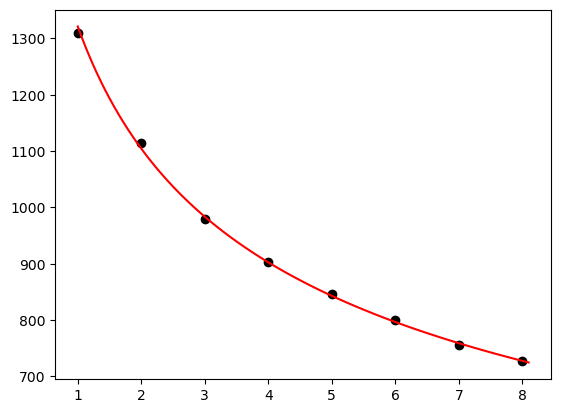

In [72]:
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

t=np.arange(1.00,9.00,1.00)
t_smooth=np.linspace(1,8.1,100)
T=np.array([1310, 1115, 979, 904, 846, 801, 756, 728])

#define Constants
T0=2000
s=5.6704e-8
rho=7910
r=0.45
c=452

def stefan(t, e):
    t = t*3600
    return T0*(1+9*s*e*T0**3*t/(rho *c *r))**(-1/3)

initial_guess=[0.5]
popt, pcov = curve_fit(stefan, t, T, p0 = initial_guess)
perr = np.sqrt(np.diag(pcov))

print(f"Value for Emissivity: {popt[0]:.3f} +/- {perr[0]:.3f}")

plt.scatter(t, T, label = "Original Data", color = "black")
plt.plot(t_smooth, stefan(t_smooth, *popt), "r", label = "Fitted Model")
plt.plot()
plt.show()
